### LSTM 셀 구현

In [1]:
#  LSTMCell

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
cuda = True if torch.cuda.is_available() else False

Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor

torch.manual_seed(125)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(125)

In [3]:
import torchvision.transforms as transforms

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (1.0,))
])

In [4]:
from torchvision.datasets import MNIST

download_root = 'MNIST_DATASET/'

train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True)
valid_dataset = MNIST(download_root, transform=mnist_transform, train=False, download=True)
test_dataset = MNIST(download_root, transform=mnist_transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.38MB/s]


In [5]:
batch_size = 64
train_loader = DataLoader(dataset=train_dataset,
                         batch_size=batch_size,
                         shuffle=True)
valid_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size,
                         shuffle=True)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size,
                         shuffle=True)

In [6]:
batch_size = 100
n_iters = 6000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

In [7]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.bias = bias
        self.x2h = nn.Linear(input_size, 4 * hidden_size, bias=bias)
        self.h2h = nn.Linear(hidden_size, 4 * hidden_size, bias=bias)
        self.reset_parameters()

    def reset_parameters(self):
        std = 1.0 / math.sqrt(self.hidden_size)
        for w in self.parameters():
            w.data.uniform_(-std, std)

    def forward(self, x, hidden):
        hx, cx = hidden
        x = x.view(-1, x.size(1))

        gates = self.x2h(x) + self.h2h(hx)
        gates = gates.squeeze()
        ingate, forgetgate, cellgate, outgate = gates.chunk(4, 1)

        ingate = F.sigmoid(ingate)
        forgetgate = F.sigmoid(forgetgate)
        cellgate = F.tanh(cellgate)
        outgate = F.sigmoid(outgate)

        cy = torch.mul(cx, forgetgate) +  torch.mul(ingate, cellgate)
        hy = torch.mul(outgate, F.tanh(cy))
        return (hy, cy)

In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, bias=True):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim

        self.layer_dim = layer_dim
        self.lstm = LSTMCell(input_dim, hidden_dim, layer_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if torch.cuda.is_available():
            h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
        else:
            h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))

        if torch.cuda.is_available():
            c0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
        else:
            c0 = Variable(torch.zeros(self.layer_dim, x.size(0), hidden_dim))

        outs = []
        cn = c0[0,:,:]
        hn = h0[0,:,:]

        for seq in range(x.size(1)):
            hn, cn = self.lstm(x[:,seq,:], (hn,cn))
            outs.append(hn)

        out = outs[-1].squeeze()
        out = self.fc(out)
        return out

In [9]:
input_dim = 28
hidden_dim = 128
layer_dim = 1
output_dim = 10

model = LSTMModel(input_dim, hidden_dim, layer_dim, output_dim)
if torch.cuda.is_available():
    model.cuda()
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [10]:
seq_dim = 28
loss_list = []
iter = 0
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            images = Variable(images.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            images = Variable(images.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()
        optimizer.step()
        loss_list.append(loss.item())
        iter += 1

        if iter % 500 == 0:
            correct = 0
            total = 0
            for images, labels in valid_loader:
                if torch.cuda.is_available():
                    images = Variable(images.view(-1, seq_dim, input_dim).cuda())
                else:
                    images = Variable(images.view(-1 , seq_dim, input_dim))

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)
                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            accuracy = 100 * correct / total
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))

Iteration: 500. Loss: 2.237457275390625. Accuracy: 21.420000076293945
Iteration: 1000. Loss: 0.9968994855880737. Accuracy: 74.94999694824219
Iteration: 1500. Loss: 0.42673957347869873. Accuracy: 88.13999938964844
Iteration: 2000. Loss: 0.30981600284576416. Accuracy: 93.56999969482422
Iteration: 2500. Loss: 0.0558248832821846. Accuracy: 95.69000244140625
Iteration: 3000. Loss: 0.09873700886964798. Accuracy: 95.58000183105469
Iteration: 3500. Loss: 0.08254366368055344. Accuracy: 96.8499984741211
Iteration: 4000. Loss: 0.03308983892202377. Accuracy: 97.08000183105469
Iteration: 4500. Loss: 0.049307383596897125. Accuracy: 97.08000183105469
Iteration: 5000. Loss: 0.08068697154521942. Accuracy: 96.69999694824219
Iteration: 5500. Loss: 0.12790139019489288. Accuracy: 97.30999755859375
Iteration: 6000. Loss: 0.007093742024153471. Accuracy: 97.66000366210938
Iteration: 6500. Loss: 0.011727366596460342. Accuracy: 97.63999938964844
Iteration: 7000. Loss: 0.008610538206994534. Accuracy: 98.06999969

In [12]:
def evaluate(model, val_iter):
    corrects, total, total_loss = 0, 0, 0
    model.eval()
    for images, labels in val_iter:
        if torch.cuda.is_available():
            images = Variable(images.view(-1, seq_dim, input_dim).cuda())
        else:
            images = Variable(images.view(-1 , seq_dim, input_dim)).to(device)
        labels = labels.cuda()
        logit = model(images).cuda()
        loss = F.cross_entropy(logit, labels, reduction = "sum")
        _, predicted = torch.max(logit.data, 1)
        total += labels.size(0)
        total_loss += loss.item()
        corrects += (predicted == labels).sum()

    avg_loss = total_loss / len(val_iter.dataset)
    avg_accuracy = corrects / total
    return avg_loss, avg_accuracy

In [13]:
test_loss, test_acc = evaluate(model,test_loader)
print("Test Loss: %5.2f | Test Accuracy: %5.2f" % (test_loss, test_acc))

Test Loss:  0.07 | Test Accuracy:  0.98


### **GRU 셀 구현 (과제)**

In [ ]:
# GRUCell

In [14]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
cuda = True if torch.cuda.is_available() else False

Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor

torch.manual_seed(125)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(125)

In [15]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (1.0,))
])

In [16]:
from torchvision.datasets import MNIST
download_root = 'MNIST_DATASET/'

train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True)
valid_dataset = MNIST(download_root, transform=mnist_transform, train=False, download=True)
test_dataset = MNIST(download_root, transform=mnist_transform, train=False, download=True)

In [17]:
batch_size = 64
train_loader = DataLoader(dataset=train_dataset,
                         batch_size=batch_size,
                         shuffle=True)
valid_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size,
                         shuffle=True)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size,
                         shuffle=True)

In [18]:
batch_size = 100
n_iters = 6000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

**과제:** 아래의 GRU 셀을 구현하세요. ### 부분을 채워주시면 됩니다.

In [23]:
class GRUCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias=True):
        super(GRUCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.bias = bias
        self.x2h = nn.Linear(input_size, 3*hidden_size, bias = bias)
        self.h2h = nn.Linear(hidden_size, 3*hidden_size, bias = bias)
        self.reset_parameters()

    def reset_parameters(self):
        std = 1.0 / math.sqrt(self.hidden_size)
        for w in self.parameters():
            w.data.uniform_(-std, std)

    def forward(self, x, hidden):
        x = x.view(-1, x.size(1))

        gate_x = self.x2h(x)
        gate_h = self.h2h(hidden)

        gate_x = gate_x.squeeze()
        gate_h = gate_h.squeeze()

        i_r, i_i, i_n =  gate_x.chunk(3, dim=-1)
        h_r, h_i, h_n =  gate_h.chunk(3, dim=-1)

        resetgate = torch.sigmoid(i_r + h_r)
        inputgate = torch.sigmoid(i_i + h_i)
        newgate = torch.tanh(i_n + resetgate * h_n)

        hy = newgate + inputgate * (hidden - newgate)
        return hy

In [24]:
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, bias=True):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.gru_cell = GRUCell(input_dim, hidden_dim, layer_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if torch.cuda.is_available():
            h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
        else:
            h0 = Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))

        outs = []
        hn = h0[0,:,:]

        for seq in range(x.size(1)):
            hn = self.gru_cell(x[:,seq,:], hn)
            outs.append(hn)

        out = outs[-1].squeeze()
        out = self.fc(out)
        return out

In [25]:
input_dim = 28
hidden_dim = 128
layer_dim = 1
output_dim = 10

model = GRUModel(input_dim, hidden_dim, layer_dim, output_dim)

if torch.cuda.is_available():
    model.cuda()

criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [26]:
seq_dim = 28
loss_list = []
iter = 0
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            images = Variable(images.view(-1, seq_dim, input_dim).cuda())
            labels = Variable(labels.cuda())
        else:
            images = Variable(images.view(-1, seq_dim, input_dim))
            labels = Variable(labels)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()
        optimizer.step()

        loss_list.append(loss.item())
        iter += 1

        if iter % 500 == 0:
            correct = 0
            total = 0
            for images, labels in valid_loader:
                if torch.cuda.is_available():
                    images = Variable(images.view(-1, seq_dim, input_dim).cuda())
                else:
                    images = Variable(images.view(-1 , seq_dim, input_dim))

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)

                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            accuracy = 100 * correct / total
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))

Iteration: 500. Loss: 1.4944429397583008. Accuracy: 52.63999938964844
Iteration: 1000. Loss: 0.6265947222709656. Accuracy: 82.12000274658203
Iteration: 1500. Loss: 0.2573416233062744. Accuracy: 90.5
Iteration: 2000. Loss: 0.31333649158477783. Accuracy: 93.7300033569336
Iteration: 2500. Loss: 0.04653281718492508. Accuracy: 95.5199966430664
Iteration: 3000. Loss: 0.08454148471355438. Accuracy: 95.94999694824219
Iteration: 3500. Loss: 0.22539710998535156. Accuracy: 96.11000061035156
Iteration: 4000. Loss: 0.03506850451231003. Accuracy: 96.58999633789062
Iteration: 4500. Loss: 0.06185426563024521. Accuracy: 96.73999786376953
Iteration: 5000. Loss: 0.07688301056623459. Accuracy: 97.2300033569336
Iteration: 5500. Loss: 0.04539097473025322. Accuracy: 97.56999969482422
Iteration: 6000. Loss: 0.03616723045706749. Accuracy: 97.44999694824219
Iteration: 6500. Loss: 0.0703456848859787. Accuracy: 97.68000030517578
Iteration: 7000. Loss: 0.013795659877359867. Accuracy: 97.41000366210938
Iteration: 7

In [27]:
def evaluate(model, val_iter):
    corrects, total, total_loss = 0, 0, 0
    model.eval()
    for images, labels in val_iter:
        if torch.cuda.is_available():
            images = Variable(images.view(-1, seq_dim, input_dim).cuda())
        else:
            images = Variable(images.view(-1 , seq_dim, input_dim)).to(device)
        labels = labels.cuda()
        logit = model(images).cuda()
        loss = F.cross_entropy(logit, labels, reduction = "sum")
        _, predicted = torch.max(logit.data, 1)
        total += labels.size(0)
        total_loss += loss.item()
        corrects += (predicted == labels).sum()

    avg_loss = total_loss / len(val_iter.dataset)
    avg_accuracy = corrects / total
    return avg_loss, avg_accuracy

In [28]:
test_loss, test_acc = evaluate(model,test_loader)
print("Test Loss: %5.2f | Test Accuracy: %5.2f" % (test_loss, test_acc))

Test Loss:  0.06 | Test Accuracy:  0.98


# 1. LSTM 기반 Seq2Seq 모델에서 디코딩할 때 사용하는 Beam Search 동작 방식에 대해서 설명.

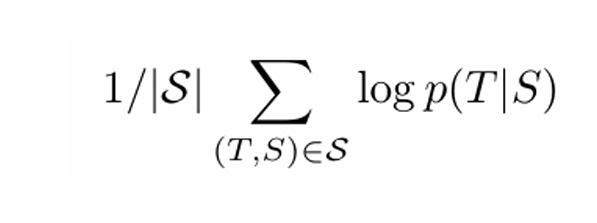 <br>

위 식은 Seq2Seq 함수의 목표 함수이다. 단어 예측은 시퀸스 예측 문제이나 시점별로 단어 사전 내의 정답을 찾아내는 Multi-class classification 문제로 볼 수 있다. 따라서 Cross-Entropy Loss 함수를 사용하고 위의 목표 함수는 Cross-Entropy Loss 함수에 -를 곱해 부호를 바꿔준 것이다. 즉, 목표함수를 최대화하는 것과 Cross-Entropy Loss 함수를 최소화하는 것은 같은 문제이다. <br>
Seq2Seq 모델에서는 이 문제를 해결하기 위해 Beam Search를 사용한다. Greedy Search는 후보 단어들의 확률 분포를 softmax로 출력하고 그 중 가장 확률이 높은 한 단어만을 출력한다. &lt;EOS&gt;는 문장 종료를 의미하며 &lt;EOS&gt;가 출력될 때까지 이 과정을 반복한다. Beam Search는 가장 확률이 높은 B개의 문장 후보군을 업데이트하며 문장을 예측한다. 즉 첫 단어에서 3개를 남기고 두 번째 단어에서 3개를 선택하면 9개의 조합이 생기며 여기서 다시 3개의 후보군만 남긴다. 이를 &lt;EOS&gt;가 나올 때까지 반복하며, &lt;EOS&gt;가 나온 문장은 완성된 문장으로 따로 저장하여 최종 완성된 3문장에서 확률이 제일 높은 하나를 선택하는 방식이다. B=1일 때의 Beam Search는 Greedy Search와 같다.

#2. Seq2Seq with LSTM 모델은 Attention이 없던 시절 제안된 구조임. 기본 Seq2Seq 모델의 한계와 이후 Attention 메커니즘이 이 한계를 어떻게 보완했는지 설명.

기본 Seq2Seq with LSTM 모델은 인코더가 입력 문장의 정보를 하나의 고정된 크기의 context vector에 압축하여 디코더에게 전달하는 방식으로 작동한다. 이 방식은 문장이 짧을 경우 잘 작동하지만, 문장의 길이가 길어진다면, 앞부분 정보가 뒤로 갈수록 희미해지고 정보 손실이 커지는 한계가 있다. Attention 메커니즘은 이 한계를 보완하기 위해 디코더가 매 시점마다 인코더의 모든 hidden state들을 참조할 수 있게 하며, 입력 문장의 각 단어가 얼마나 중요한지 가중치를 계산해 매번 달라지는 context vector를 만들어낸다. 이를 통해 고정된 벡터의 정보 손실 문제를 해결하고 긴 문장에서도 주요 정보를 잘 유지하며 예측 성능을 높일 수 있다.